# 07 · Q-LIME vs TN-SHAP-Q: ranking agreement

**Computes.** Q-LIME (Pira \& Ferrie 2024) is a local *linear* surrogate, **not** a Shapley method, so we compare it to TN-SHAP-Q on **ranking only** (no magnitude MAE). On the Iris QNN ($d=4$) we grow the Q-LIME perturbation budget $16\to512$ and measure Spearman, Kendall-$\tau$, and top-1 agreement of its feature ordering against the exact TN-SHAP-Q Shapley ordering. The agreement **saturates below 1** independent of budget: surrogate bias, not sampling, is the ceiling.

**Produces.** `figures/fig_qlime.png` and `results/07.json`.

**Seed.** Fixed: Q-LIME seeds 0..4 averaged over an 8-instance cohort.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
import tnshapq as T
from tnshapq import datasets, exact, owen, qlime, metrics
from tnshapq.io_utils import save_results, savefig

np.random.seed(0)
plt.rcParams.update({'font.size': 13, 'axes.titlesize': 13, 'axes.labelsize': 13,
                     'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11})
D = 4
BUDGETS = [16, 32, 64, 128, 256, 512]
SEEDS = [0, 1, 2, 3, 4]

In [2]:
X, y, baseline, qnn, acc = datasets.iris_qnn(D)
cohort = datasets.pick_instances(X, 8, seed=123)
# Exact TN-SHAP-Q Shapley (Owen M=2 == enumeration) is the ground-truth ranking
phi_ref = [owen.owen_integral_shapley(qnn, D, x, baseline, T.threshold_M(D, 1))[0]
           for _, x in cohort]
print(f"Iris d={D}, acc={acc:.3f}; reference = exact TN-SHAP-Q Shapley for {len(cohort)} instances")

Iris d=4, acc=0.970; reference = exact TN-SHAP-Q Shapley for 8 instances


In [3]:
# Q-LIME ranking agreement vs perturbation budget (averaged over instances x seeds)
sp, kt, t1 = [], [], []
for B in BUDGETS:
    S, K, T1 = [], [], []
    for (idx, x), phi in zip(cohort, phi_ref):
        game = T.FeatureGame(qnn, x, baseline, target="class1")
        for s in SEEDS:
            beta, _r2 = qlime.qlime_explain(game, shots=None, seed=s, M=B)
            S.append(metrics.spearman(beta, phi))
            K.append(metrics.kendall_tau(beta, phi))
            T1.append(metrics.top1_agreement(beta, phi))
    sp.append(float(np.mean(S))); kt.append(float(np.mean(K))); t1.append(float(np.mean(T1)))
    print(f"budget {B:4d}: Spearman={sp[-1]:.3f}  Kendall={kt[-1]:.3f}  top-1={t1[-1]:.3f}")

budget   16: Spearman=0.885  Kendall=0.825  top-1=0.725


budget   32: Spearman=0.955  Kendall=0.925  top-1=0.875


budget   64: Spearman=0.955  Kendall=0.925  top-1=0.875


budget  128: Spearman=0.950  Kendall=0.917  top-1=0.875


budget  256: Spearman=0.950  Kendall=0.917  top-1=0.875


budget  512: Spearman=0.950  Kendall=0.917  top-1=0.875


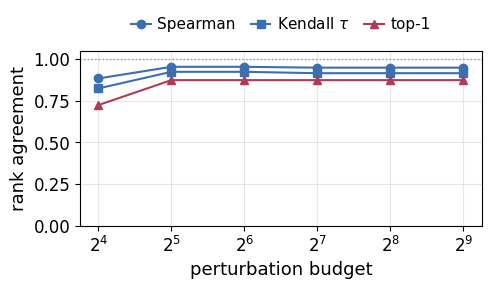

saved figures/fig_qlime.png


In [4]:
# Figure: ranking agreement saturates below 1 as the budget grows
fig, ax = plt.subplots(figsize=(5.0, 3.1))
ax.semilogx(BUDGETS, sp, 'o-', color='#3b6fb0', base=2, label='Spearman')
ax.semilogx(BUDGETS, kt, 's-', color='#3b6fb0', base=2, label=r'Kendall $\tau$')
ax.semilogx(BUDGETS, t1, '^-', color='#b03b54', base=2, label='top-1')
ax.axhline(1.0, color='0.6', ls=':', lw=1)
ax.set_ylim(0, 1.05)
ax.set_xlabel('perturbation budget'); ax.set_ylabel('rank agreement')

ax.legend(frameon=False, loc='lower center', bbox_to_anchor=(0.5, 1.03), ncol=3, columnspacing=1.0, handlelength=1.3, handletextpad=0.4); ax.grid(alpha=0.3, which='both')
fig.tight_layout()
savefig(fig, 'fig_qlime.png')
plt.show()
print("saved figures/fig_qlime.png")

In [5]:
res = {
    "task": "Q-LIME ranking agreement vs TN-SHAP-Q (Iris d=4)",
    "d": D, "budgets": BUDGETS, "seeds": SEEDS, "cohort_size": len(cohort),
    "spearman": sp, "kendall": kt, "top1": t1,
    "spearman_saturation": float(sp[-1]), "kendall_saturation": float(kt[-1]),
    "top1_saturation": float(t1[-1]), "ranking_only": True,
}
save_results("07", res)
print("saved results/07.json")

saved results/07.json


In [6]:
# Verification: ranking agreement is bounded away from 1 even at the largest budget
assert sp[-1] < 0.98, "Q-LIME should NOT perfectly recover the Shapley ranking"
assert sp[-1] > 0.4, "sanity: some positive rank agreement expected"
print(f"PASS  Q-LIME rank agreement saturates at Spearman={sp[-1]:.3f}, Kendall={kt[-1]:.3f}, "
      f"top-1={t1[-1]:.3f} (budget {BUDGETS[-1]}) -- bounded below 1 by surrogate bias.")

PASS  Q-LIME rank agreement saturates at Spearman=0.950, Kendall=0.917, top-1=0.875 (budget 512) -- bounded below 1 by surrogate bias.
